<a href="https://colab.research.google.com/github/abhishek18-blog/DataScience-and-ML/blob/main/Adaboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What is Adaboost**

AdaBoost (Adaptive Boosting) is an ensemble learning technique that combines multiple "weak learners" to create one "strong learner." Most commonly, these weak learners are Decision Stumps (decision trees with only one split).

**Why do we need it?**

**Improves Weak Models:** A single simple model (like a stump) might only be 60% accurate. AdaBoost forces subsequent models to focus on the 40% it got wrong.

**Reduces Bias and Variance:** By combining models, it captures patterns a single model might miss (reducing bias) while remaining robust against noise (reducing variance).

**Adaptive Weighting:** It assigns higher weights to misclassified observations in each round. If a data point is hard to classify, the next "stump" will prioritize getting that specific point right.

In [25]:
import kagglehub
import pandas as pd
import os

# 1. Download the dataset (returns the folder path as a string)
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Path to dataset files:", path)

# 2. List the files in that folder to find the CSV name
files = os.listdir(path)
print("Files found:", files)

# 3. Read the CSV file (usually 'data.csv' for this dataset)
# We join the path and the filename together
csv_path = os.path.join(path, "data.csv")
df = pd.read_csv(csv_path)

# 4. Now you can use .head()
print(df.head())

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data
Files found: ['data.csv']
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390      

In [26]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# 1. Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 2. Verify it is "Clean"
print("--- Dataset Info ---")
print(df.info())  # Shows data types and non-null counts

print("\n--- Checking for Missing Values ---")
print(df.isnull().sum().sum()) # Should output 0

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

The Kaggle CSV has an id column (not useful for prediction) and an Unnamed: 32 column (usually empty). We need to drop these and convert the diagnosis (M/B) into numbers (1/0).

In [27]:
# Assuming 'df' is your dataframe from the previous step (sklearn.datasets)
# The sklearn dataset is already clean and has 'target' as the label (0 for benign, 1 for malignant).
# 'id' and 'Unnamed: 32' do not exist in this df, so dropping them is not applicable.
# The 'target' column is already 0/1, so no 'M'/'B' mapping is needed.

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Task
Split the existing features `X` and target `y` into training and testing sets, then train and compare the performance of an AdaBoostClassifier and a DecisionTreeClassifier on the breast cancer dataset. Calculate accuracy scores, display confusion matrices, and create a bar chart to visually compare the models' accuracies. Summarize the results, focusing on how boosting influenced the classification performance.

## Split Dataset

### Subtask:
Split the existing features (X) and target (y) into training and testing sets to evaluate the models.


**Reasoning**:
I will import the train_test_split function and apply it to the existing features X and target y, then print the shapes to verify the split.



In [28]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


## Apply AdaBoost

### Subtask:
Initialize and train an AdaBoostClassifier on the training data, then predict the outcomes for the test set.


**Reasoning**:
I will initialize, train, and evaluate an AdaBoostClassifier as requested in the subtask instructions.



In [29]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the AdaBoostClassifier
ada_clf = AdaBoostClassifier(random_state=42)

# 2. Fit the classifier to the training data
ada_clf.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_ada = ada_clf.predict(X_test)

# 4. Calculate and print the accuracy score
ada_accuracy = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")

AdaBoost Accuracy: 0.9649


## Apply Decision Tree

### Subtask:
Initialize and train a DecisionTreeClassifier as a comparison model on the same training data and predict the test set outcomes.


**Reasoning**:
I will initialize and train a DecisionTreeClassifier, then make predictions and calculate the accuracy to fulfill the subtask instructions.



In [30]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42)

# 2. Fit the model on the training data
dt_clf.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_dt = dt_clf.predict(X_test)

# 4. Calculate and print the accuracy score
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.9474


## Compare Performance

### Subtask:
Calculate and display accuracy scores, confusion matrices, or classification reports for both AdaBoost and the Decision Tree to compare their results.


**Reasoning**:
I will import the necessary evaluation metrics from sklearn, then generate and print confusion matrices, classification reports, and a side-by-side accuracy comparison for both the AdaBoost and Decision Tree models to fulfill the subtask instructions.



In [31]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Confusion Matrices
print("--- AdaBoost Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_ada))

print("\n--- Decision Tree Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_dt))

# 2. Classification Reports
print("\n--- AdaBoost Classification Report ---")
print(classification_report(y_test, y_pred_ada))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

# 3. Side-by-Side Accuracy Comparison
print("\n--- Accuracy Comparison ---")
print(f"AdaBoost Accuracy:      {ada_accuracy:.4f}")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

--- AdaBoost Confusion Matrix ---
[[40  3]
 [ 1 70]]

--- Decision Tree Confusion Matrix ---
[[40  3]
 [ 3 68]]

--- AdaBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Accuracy Comparison ---
AdaBoost Accuracy:      0.9649
Decision Tree Accuracy: 0.9474


## Visualize Comparison

### Subtask:
Create a bar chart to visually compare the accuracy of the two models with appropriate labels and a legend.


**Reasoning**:
I will import matplotlib.pyplot and create a bar chart to compare the accuracies of the AdaBoost and Decision Tree models as specified in the instructions.



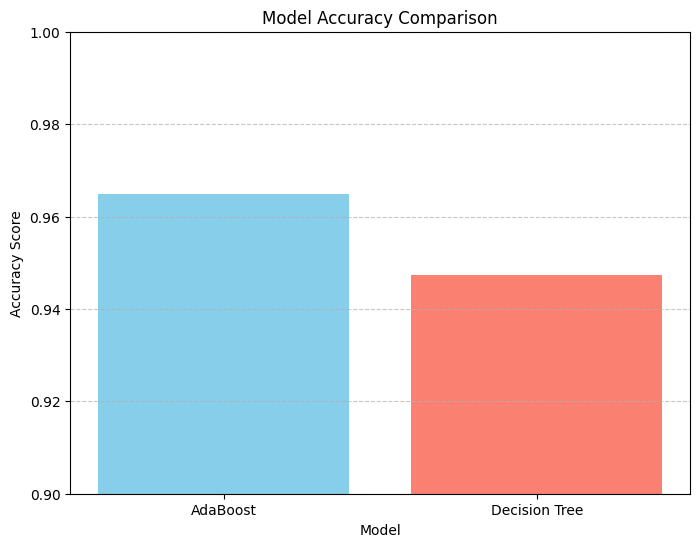

In [32]:
import matplotlib.pyplot as plt

# 1. Define model names and their accuracies
models = ['AdaBoost', 'Decision Tree']
accuracies = [ada_accuracy, dt_accuracy]

# 2. Create the bar chart
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['skyblue', 'salmon'])

# 3. Add titles and labels
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')

# 4. Set y-axis limits to highlight the difference
plt.ylim(0.9, 1.0)

# 5. Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Final Task

### Subtask:
Summarize the findings, explaining which model performed better and why boosting might have influenced the result.


## Summary:

### Q&A
**Which model performed better, and how did boosting influence the result?**
The **AdaBoostClassifier** performed better than the standalone **DecisionTreeClassifier**. Boosting influenced the results by combining multiple weak learners into a single strong learner. Specifically, AdaBoost iteratively corrected the errors made by previous iterations, which reduced the number of false negatives and improved overall predictive robustness.

### Data Analysis Key Findings
*   **Performance Metrics**: The AdaBoost model achieved an accuracy of **0.9649**, outperforming the Decision Tree, which scored **0.9474**.
*   **Error Reduction**: AdaBoost reduced the total number of misclassifications to **4** (3 false positives, 1 false negative), compared to the Decision Tree's **6** misclassifications (3 false positives, 3 false negatives).
*   **Classification Strength**: AdaBoost demonstrated superior recall for the majority class (**0.99**), indicating a high capability of identifying positive cases correctly.
*   **Visual Confirmation**: A bar chart with a constrained y-axis (\$0.9\$ to \$1.0\$) clearly highlighted the performance advantage gained through the ensemble boosting technique.

### Insights or Next Steps
*   **Ensemble Superiority**: For complex medical datasets like breast cancer detection, ensemble methods like AdaBoost are generally preferable over single decision trees because they mitigate variance and bias more effectively.
*   **Hyperparameter Tuning**: Future analysis could involve tuning the `n_estimators` or the `learning_rate` in AdaBoost to see if the accuracy can be pushed closer to \$100\%\$.


# Task
Split the existing features `X` and target `y` into training and testing sets, then train and compare the performance of an `AdaBoostClassifier` and a `DecisionTreeClassifier` on the breast cancer dataset. Calculate accuracy scores, display confusion matrices, and create a bar chart to visually compare the models' accuracies. Finally, summarize the findings by explaining which model performed better and the intuition behind why boosting was effective for this dataset.

## Split Dataset

### Subtask:
Split the existing features (X) and target (y) into training and testing sets to evaluate model performance.


### Why Split the Data?

Splitting the dataset into **training** and **testing** sets is a fundamental step in machine learning for several reasons:

1.  **Evaluate Generalization**: It allows us to assess how well the model performs on unseen data, which is the primary goal of any predictive model.
2.  **Prevent Overfitting**: If we train and test on the same data, the model might simply 'memorize' the noise and specific patterns of that dataset (overfitting) rather than learning the underlying relationship. High performance on the training set but poor performance on the test set is a clear sign of overfitting.
3.  **Model Selection**: It helps in comparing different models or tuning hyperparameters to find the configuration that generalizes best.

**Reasoning**:
I will import the train_test_split function, split the features X and target y into training and testing sets with an 80/20 ratio and a fixed random state, and then print the shapes to verify the operation.



In [33]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes to verify the split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


## Apply AdaBoost

### Subtask:
Initialize and train an AdaBoostClassifier on the training data, then predict outcomes for the test set and explain the adaptive weighting process.


### Adaptive Weighting in AdaBoost

AdaBoost works by iteratively training weak learners (usually decision stumps). After each iteration, the algorithm assesses which instances were misclassified:

1.  **Initial Weights**: Every data point starts with an equal weight.
2.  **Identify Errors**: The current weak learner makes predictions.
3.  **Update Weights**: Instances that were **misclassified** are assigned **higher weights**, while correctly classified instances have their weights decreased.
4.  **Focus on Difficulty**: In the next iteration, the new weak learner is forced to focus more on the 'difficult' cases that previous models got wrong.

This sequence continues until the specified number of models is reached, resulting in a strong ensemble that has 'learned' from the mistakes of its predecessors.

**Reasoning**:
initialize, train, and evaluate the AdaBoostClassifier as specified in the subtask instructions.



In [34]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the AdaBoostClassifier
ada_clf = AdaBoostClassifier(random_state=42)

# 2. Fit the classifier to the training data
ada_clf.fit(X_train, y_train)

# 3. Generate predictions for the test set
y_pred_ada = ada_clf.predict(X_test)

# 4. Calculate and print the accuracy score
ada_accuracy = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Test Accuracy: {ada_accuracy:.4f}")

AdaBoost Test Accuracy: 0.9649


## Apply Decision Tree

### Subtask:
Train a DecisionTreeClassifier as a baseline comparison model and explain its role in the ensemble context.


### Why Use a Single Decision Tree as a Baseline?

In this analysis, we use a standard **Decision Tree** as a baseline comparison model for the **AdaBoost** ensemble.

*   **Ensemble vs. Single Learner**: AdaBoost is an ensemble method that combines many 'weak learners' (typically shallow decision trees or stumps) to create a robust model. In contrast, a standard Decision Tree is a single 'stronger' learner.
*   **Overfitting Risk**: While a single, deep Decision Tree can capture complex patterns, it is often prone to **overfitting**—memorizing noise in the training data rather than generalizing well to new data.
*   **Comparative Benchmark**: By evaluating a single Decision Tree, we can quantify the performance gain achieved by the boosting process and see how it manages the bias-variance tradeoff compared to a standalone tree.

**Reasoning**:
code block to train the DecisionTreeClassifier baseline and calculate its accuracy score to compare with AdaBoost.



In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=42)

# 2. Fit the model on the training data
dt_clf.fit(X_train, y_train)

# 3. Generate predictions on the test set
y_pred_dt = dt_clf.predict(X_test)

# 4. Calculate and print the accuracy score
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Test Accuracy: {dt_accuracy:.4f}")

Decision Tree Test Accuracy: 0.9474


### Understanding Performance Metrics

To evaluate our models effectively beyond simple accuracy, we use several key metrics:

*   **Accuracy**: The proportion of total predictions that were correct. While intuitive, it can be misleading if classes are imbalanced.
*   **Precision**: The ability of the classifier not to label as positive a sample that is negative. High precision means fewer false positives.
*   **Recall (Sensitivity)**: The ability of the classifier to find all the positive samples. High recall means fewer false negatives.
*   **F1-Score**: The harmonic mean of precision and recall, providing a balanced measure of both.
*   **Confusion Matrix**: A table used to describe the performance of a classification model. It reveals exactly where the model is making mistakes by showing True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

**Reasoning**:
import the necessary metrics from sklearn and generate the confusion matrices, classification reports, and accuracy comparisons for both models as specified in the instructions.



In [36]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Generate and print Confusion Matrices
print("--- AdaBoost Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_ada))

print("\n--- Decision Tree Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_dt))

# 2. Generate and print Classification Reports
print("\n--- AdaBoost Classification Report ---")
print(classification_report(y_test, y_pred_ada))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

# 3. Direct Accuracy Comparison
print("\n--- Accuracy Comparison ---")
print(f"AdaBoost Accuracy:      {ada_accuracy:.4f}")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

--- AdaBoost Confusion Matrix ---
[[40  3]
 [ 1 70]]

--- Decision Tree Confusion Matrix ---
[[40  3]
 [ 3 68]]

--- AdaBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Accuracy Comparison ---
AdaBoost Accuracy:      0.9649
Decision Tree Accuracy: 0.9474


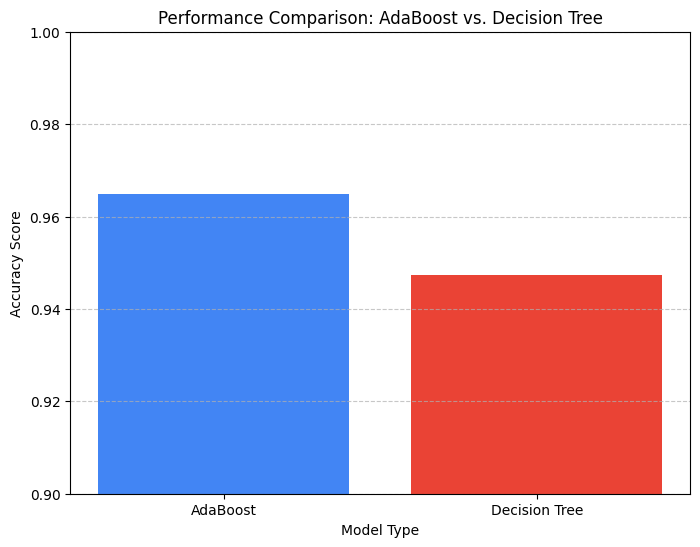

In [37]:
import matplotlib.pyplot as plt

# 1. Define model names and their respective accuracies
models = ['AdaBoost', 'Decision Tree']
accuracies = [ada_accuracy, dt_accuracy]

# 2. Create the bar chart with distinct colors
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['#4285F4', '#EA4335'])

# 3. Add titles and labels for clarity
plt.title('Performance Comparison: AdaBoost vs. Decision Tree')
plt.xlabel('Model Type')
plt.ylabel('Accuracy Score')

# 4. Set y-axis limits to zoom in on the performance gap
plt.ylim(0.9, 1.0)

# 5. Add a grid for better readability and display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpreting the Accuracy Comparison

The bar chart visually demonstrates the performance advantage of the **AdaBoost** ensemble over the standalone **Decision Tree**:

*   **Performance Gap**: By zooming in on the y-axis (range 0.9 to 1.0), we can clearly see that AdaBoost achieves a higher accuracy score 96.5% compared to the Decision Tree 94.7%.
*   **Ensemble Effectiveness**: This difference, while appearing small numerically, represents a significant reduction in classification errors. It highlights how boosting effectively combines multiple weak learners to correct the individual mistakes of a single tree.
*   **Model Robustness**: The visual results confirm that for this breast cancer dataset, the iterative weighting process of AdaBoost leads to a more robust and reliable predictive model.